# Mobile Addiction Classification
## Pipeline + Multi-Model GridSearchCV + MLflow Tracking

### Bugs Fixed:
1. **`param_grid` key mismatch** — was `'classifier'` but pipeline step was named `'rf'`. Fixed by renaming the pipeline step to `'classifier'`.
2. **`StringDtype` error** — Pandas 2.x reads CSV string columns as `StringDtype` which breaks `ColumnTransformer`. Fixed by explicitly converting to `object` dtype.
3. **Multi-model GridSearch** — Restructured to loop over models with correct parameter naming.
4. **MLflow** — Added full experiment tracking with metrics, params, and model logging.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, recall_score,
    classification_report, confusion_matrix
)

print("All imports successful")

All imports successful


## 1. Load & Explore Data

In [3]:
# Load data
data = pd.read_csv("mobile_addiction.csv")

# Drop unnamed index column if present
if data.columns[0].startswith('Unnamed'):
    data = data.drop(data.columns[0], axis=1)

print(f"Shape: {data.shape}")
data.head()

Shape: (13589, 11)


,daily_screen_time,app_sessions,social_media_usage,gaming_time,notifications,night_usage,age,work_study_hours,stress_level,apps_installed,addicted
0,2,29,0,0,49,0,44,5,3,35,not addicted
1,6,29,1,2,65,1,29,5,9,21,addicted
2,9,28,2,0,57,3,28,7,5,39,addicted
3,6,39,2,0,69,1,28,6,8,24,addicted
4,5,37,3,1,64,2,27,4,5,26,addicted


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13589 entries, 0 to 13588
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   daily_screen_time   13589 non-null  int64 
 1   app_sessions        13589 non-null  int64 
 2   social_media_usage  13589 non-null  int64 
 3   gaming_time         13589 non-null  int64 
 4   notifications       13589 non-null  int64 
 5   night_usage         13589 non-null  int64 
 6   age                 13589 non-null  int64 
 7   work_study_hours    13589 non-null  int64 
 8   stress_level        13589 non-null  int64 
 9   apps_installed      13589 non-null  int64 
 10  addicted            13589 non-null  object
dtypes: int64(10), object(1)
memory usage: 1.1+ MB


addicted
addicted        6846
not addicted    6743
Name: count, dtype: int64


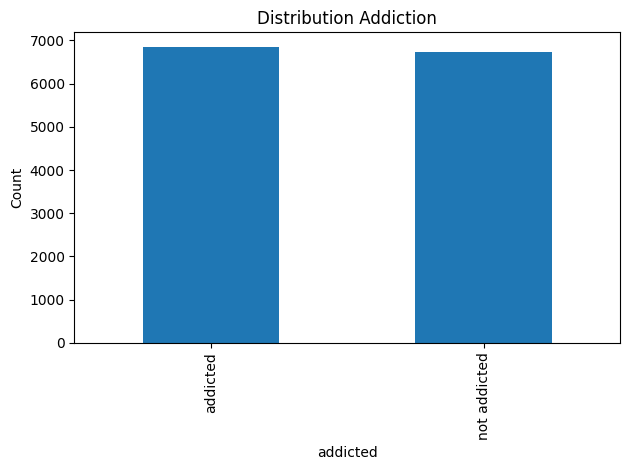

In [5]:
print(data['addicted'].value_counts())
data['addicted'].value_counts().plot(kind='bar', title='Distribution Addiction')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 2. Preprocessing

### Bug Fix #2: `StringDtype` → `object`
Pandas 2.x reads CSV string columns as `StringDtype` which is incompatible with sklearn's `ColumnTransformer`.
We must convert them to `object` dtype explicitly.

In [6]:
# FIX: Convert StringDtype columns to object (Pandas 2.x compatibility)
# This resolves: TypeError: Cannot interpret '<StringDtype(na_value=nan)>' as a data type
for col in data.columns:
    if hasattr(data[col].dtype, 'name') and 'string' in str(data[col].dtype).lower():
        data[col] = data[col].astype('object')
    elif data[col].dtype == 'object':
        data[col] = data[col].astype('object')

print("Dtypes after fix:")
print(data.dtypes)

Dtypes after fix:
daily_screen_time      int64
app_sessions           int64
social_media_usage     int64
gaming_time            int64
notifications          int64
night_usage            int64
age                    int64
work_study_hours       int64
stress_level           int64
apps_installed         int64
addicted              object
dtype: object


In [7]:
# Define X and y
target = 'addicted'
X = data.drop(target, axis=1)

# Encode target: 'addicted' -> 1, 'not addicted' -> 0
y = data[target].map({'addicted': 1, 'not addicted': 0})

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

X shape: (13589, 10)
y distribution:
addicted
1    6846
0    6743
Name: count, dtype: int64


In [8]:
# Train / test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 10871 | Test size: 2718


In [9]:
# Separate numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

Numeric columns (10): ['daily_screen_time', 'app_sessions', 'social_media_usage', 'gaming_time', 'notifications', 'night_usage', 'age', 'work_study_hours', 'stress_level', 'apps_installed']
Categorical columns (0): []


## 3. Build Preprocessing Pipeline

In [10]:
# Numeric pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Categorical pipeline
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ] if cat_cols else [
        ('num', num_transformer, num_cols)
    ]
)

print("Preprocessor built successfully")

Preprocessor built successfully


## 4. Multi-Model GridSearchCV with MLflow

### Bug Fix #1: `param_grid` key naming
When using `GridSearchCV` with a `Pipeline`, parameters must be prefixed with the **exact step name** from the pipeline:
- Pipeline step name: `'classifier'` → param key: `'classifier__n_estimators'`
- The original code used `'rf'` as the step name but `'classifier'` as the grid key — this caused the `ValueError`.

In [11]:
# Define models and their hyperparameter grids
# NOTE: Pipeline step is named 'classifier', so all param keys start with 'classifier__'
models = [
    {
        'name': 'RandomForest',
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__max_depth': [None, 5, 10],
            'classifier__min_samples_split': [2, 5]
        }
    },
    {
        'name': 'GradientBoosting',
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5]
        }
    },
    {
        'name': 'XGBoost',
        'model': XGBClassifier(
            eval_metric='logloss',
            random_state=42,
            verbosity=0
        ),
        'params': {
            'classifier__n_estimators': [50, 100],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5]
        }
    }
]

print(f"{len(models)} models configured")

3 models configured


In [12]:
# Set up MLflow experiment
mlflow.set_experiment("mobile_addiction_classification")

best_overall = {'model_name': None, 'f1': 0, 'pipeline': None, 'params': None}
results_summary = []

for m in models:
    model_name = m['name']
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    # Build full pipeline: preprocessing + classifier
    # IMPORTANT: Step must be named 'classifier' to match param_grid keys
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', m['model'])   # <-- step name MUST match param_grid prefix
    ])

    # GridSearchCV
    grid = GridSearchCV(
        pipeline,
        m['params'],
        cv=3,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)

    # Evaluate best estimator on test set
    best_pipeline = grid.best_estimator_
    y_pred = best_pipeline.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    cv_f1 = grid.best_score_

    print(f"Best params:  {grid.best_params_}")
    print(f"CV F1 (train): {cv_f1:.4f}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test F1:       {f1:.4f}")
    print(f"Test Recall:   {rec:.4f}")

    # Log to MLflow
    with mlflow.start_run(run_name=model_name):
        # Log hyperparameters
        mlflow.log_param("model", model_name)
        for k, v in grid.best_params_.items():
            mlflow.log_param(k, v)

        # Log metrics
        mlflow.log_metric("cv_f1", cv_f1)
        mlflow.log_metric("test_accuracy", acc)
        mlflow.log_metric("test_f1", f1)
        mlflow.log_metric("test_recall", rec)

        # Log the trained pipeline as a model artifact
        mlflow.sklearn.log_model(best_pipeline, artifact_path=f"{model_name}_pipeline")

    results_summary.append({
        'Model': model_name,
        'CV_F1': round(cv_f1, 4),
        'Test_Accuracy': round(acc, 4),
        'Test_F1': round(f1, 4),
        'Test_Recall': round(rec, 4),
        'Best_Params': grid.best_params_
    })

    # Track overall best
    if f1 > best_overall['f1']:
        best_overall.update({
            'model_name': model_name,
            'f1': f1,
            'pipeline': best_pipeline,
            'params': grid.best_params_
        })

print(f"\n{'='*50}")
print("Training complete!")

2026/03/04 10:14:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/04 10:14:34 INFO mlflow.store.db.utils: Updating database tables
2026/03/04 10:14:36 INFO mlflow.tracking.fluent: Experiment with name 'mobile_addiction_classification' does not exist. Creating a new experiment.



Training: RandomForest
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params:  {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
CV F1 (train): 0.9792
Test Accuracy: 0.9779
Test F1:       0.9781
Test Recall:   0.9803


2026/03/04 10:14:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 10:14:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training: GradientBoosting
Fitting 3 folds for each of 8 candidates, totalling 24 fits


2026/03/04 10:15:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 10:15:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best params:  {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
CV F1 (train): 0.9803
Test Accuracy: 0.9783
Test F1:       0.9785
Test Recall:   0.9817

Training: XGBoost
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params:  {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
CV F1 (train): 0.9803
Test Accuracy: 0.9798
Test F1:       0.9800
Test Recall:   0.9825


2026/03/04 10:15:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 10:15:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training complete!


## 5. Results Summary

In [13]:
results_df = pd.DataFrame(results_summary)[['Model', 'CV_F1', 'Test_Accuracy', 'Test_F1', 'Test_Recall']]
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))
results_df


=== Model Comparison ===
           Model  CV_F1  Test_Accuracy  Test_F1  Test_Recall
    RandomForest 0.9792         0.9779   0.9781       0.9803
GradientBoosting 0.9803         0.9783   0.9785       0.9817
         XGBoost 0.9803         0.9798   0.9800       0.9825


,Model,CV_F1,Test_Accuracy,Test_F1,Test_Recall
0,RandomForest,0.9792,0.9779,0.9781,0.9803
1,GradientBoosting,0.9803,0.9783,0.9785,0.9817
2,XGBoost,0.9803,0.9798,0.9800,0.9825


In [14]:
print(f"\n=== Best Model: {best_overall['model_name']} ===")
print(f"Test F1 Score: {best_overall['f1']:.4f}")
print(f"Best Params:   {best_overall['params']}")


=== Best Model: XGBoost ===
Test F1 Score: 0.9800
Best Params:   {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}


In [15]:
# Detailed report for the best model
best_pipeline = best_overall['pipeline']
y_pred_best = best_pipeline.predict(X_test)

print(f"Classification Report — {best_overall['model_name']}")
print(classification_report(y_test, y_pred_best, target_names=['not addicted', 'addicted']))

Classification Report — XGBoost
              precision    recall  f1-score   support

not addicted       0.98      0.98      0.98      1349
    addicted       0.98      0.98      0.98      1369

    accuracy                           0.98      2718
   macro avg       0.98      0.98      0.98      2718
weighted avg       0.98      0.98      0.98      2718



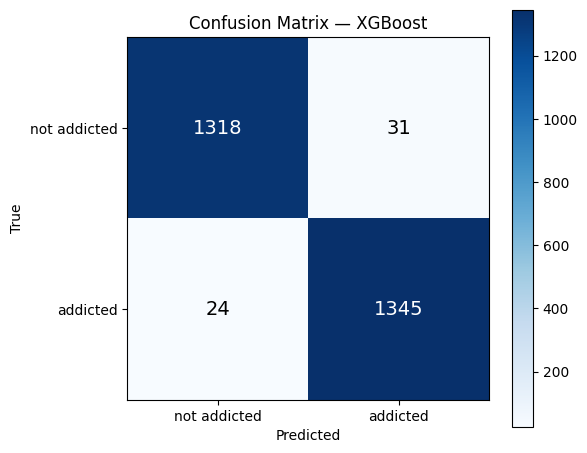

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['not addicted', 'addicted'])
ax.set_yticklabels(['not addicted', 'addicted'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_overall["model_name"]}')
plt.colorbar(im)
plt.tight_layout()
plt.show()